In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import cartopy.crs as ccrs

# To ignore warnings
import warnings
warnings.filterwarnings("ignore")

import seaborn as sns
sns.set_theme(style="whitegrid")
sns.set_context('notebook', font_scale=1.0)

# Import the module
import cartogrid as cg

Let’s start by loading some the temperature data and computing anomalies before creating any plots:

In [2]:
# Open the netCDF dataset
ds = xr.open_dataset('dummy_data/air.2m.gauss.2022.nc')


# Convert Kelvin → Celsius
air = ds['air'] - 273.15

# --- Compute climatology and anomalies ---
# Time-mean climatology (lat, lon)
climatology = air.mean(dim='time')

# Anomalies (time, lat, lon)
air_anom = air - climatology


# Extract coordinates
time = pd.to_datetime(ds['time'].values)
lat = ds['lat'].values
lon = ds['lon'].values

The following cell builds a custom grid of map subplots using manually positioned axes instead of plt.subplots(). This approach provides full control over subplot placement, spacing, and colorbar positioning.

### 1. Defining the Figure

`fig = plt.figure(figsize=(14, 6))`

We first create a blank figure. No axes exist yet—those will be added manually inside the loop.


### 2. Setting the Number of Rows and Columns


`num_rows = 2
num_columns = 3`

This determines how many subplots (maps) will appear in the final figure.

* Rows: counted from top (0) to bottom (1)
* Columns: counted from left (0) to right (2)

So subplot (row=0, col=0) is the top-left, and (row=1, col=2) is the bottom-right.


### 3. Using define_grid_fig() to Get Axes Positions
`
grid_prop = x_coords, y_coords, x_fig, y_fig = cg.define_grid_fig(num_rows, num_columns)
`


This helper function computes:

* `x_coords`: list of left positions for each column
* `y_coords`: list of bottom positions for each row
* `x_fig`: width of each subplot
* `y_fig`: height of each subplot

These values ensure the subplots are evenly spaced and fill the figure neatly.


### 4. Creating Each Subplot in the Row–Column Loop

``` python
for ri in range(num_rows):
    for ci in range(num_columns):
        ax = fig.add_axes([x_coords[ci], y_coords[ri], x_fig, y_fig],
                          projection=proj)
```

Each subplot is added to the figure using its calculated position.

* `ri` = row index
* `ci` = column index

The subplot is positioned using `[left, bottom, width, height]`.

A label like this helps visualize where each subplot is located:

`ax.text(0.02, 0.95, f'(row: {ri}, col: {ci})', ...)`


### 5. Hiding Tick Labels When Needed

To avoid clutter:

* All subplots except the first column hide y-labels
* All subplots except the last row hide x-labels

This preserves the grid structure while keeping the figure clean.

### 6. Adding Colorbars for the Entire Figure

At the end, a single colorbar (or more than one) can be added for the whole figure:
```python
cg.add_colorbar(fig=fig, cs=cs, orientation='horizontal', ...)
cg.add_colorbar(fig=fig, cs=cs, orientation='vertical', ...)
```

Because we manually define axes locations, the colorbar function uses:

* `cbar_factor`: how wide/tall the colorbar is relative to the subplot grid
* `cbar_width`: actual thickness of the colorbar
* `y_coord_cbar`: vertical shift (for horizontal bars)

This ensures the colorbar aligns with the full grid, not just one subplot.












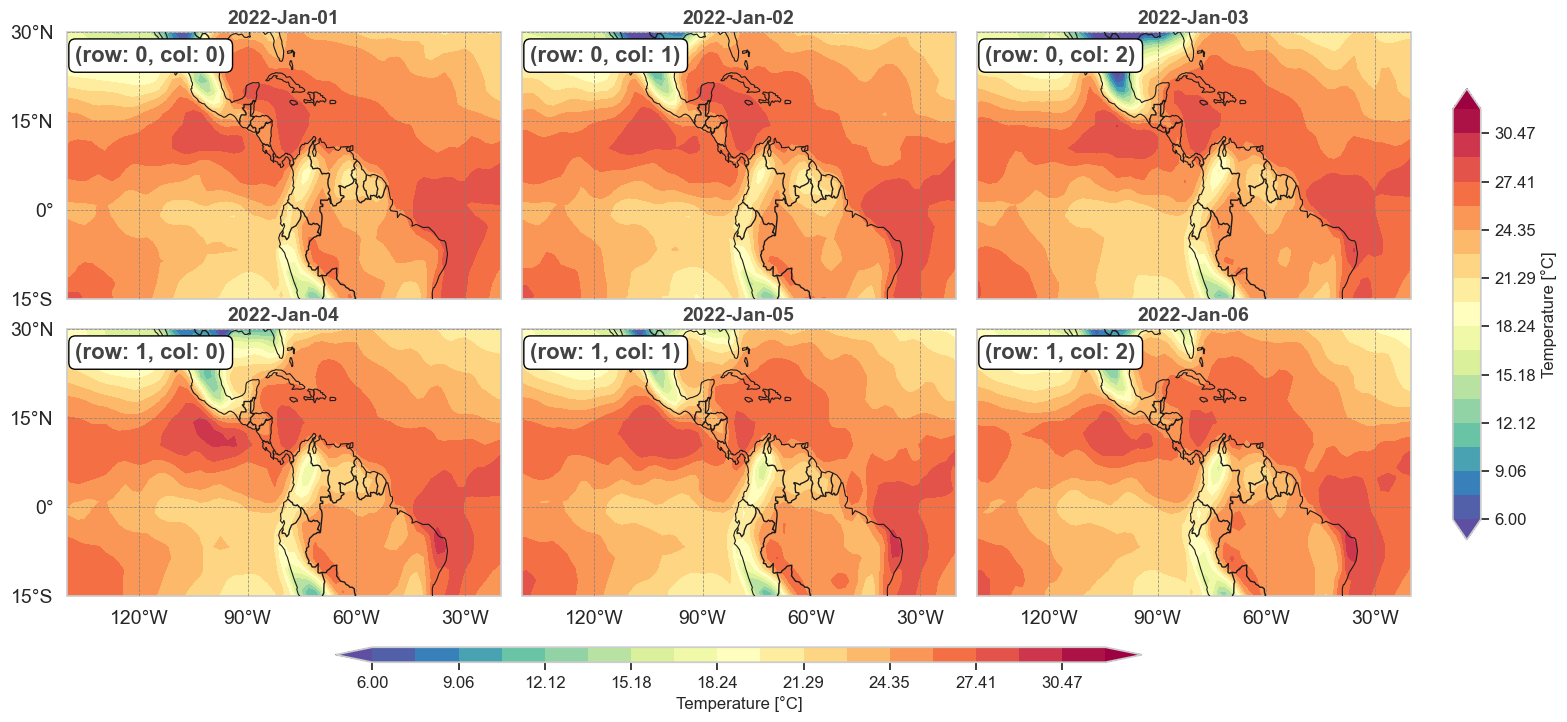

In [3]:
# Define the map projection (PlateCarree) and set the image extent
proj = ccrs.PlateCarree(central_longitude=0)
img_extent = (-140, -20, -15, 30)

# Define the grid size (number of rows and columns)
num_rows = 2
num_columns = 3

# Use the function to calculate properties of the grid
grid_prop = x_coords, y_coords, x_fig, y_fig = cg.define_grid_fig(
    num_rows, num_columns)

# Define font properties for axis labels and title
font_prop = {'fontsize': 16, 'fontweight': 'semibold', 'color': '#434343'}
font_prop_title = {'fontsize': 14,
                   'fontweight': 'semibold', 'color': '#434343'}

# Create a figure with a specified size
fig = plt.figure(figsize=(14, 6))

# Initialize the index for selecting time slices of the temperature data
idx = 0
# Define the contour levels for the temperature plot
levels = np.linspace(6, 32, 18)

# Define the colormap for the plot
cmap = sns.color_palette("Spectral_r", as_cmap=True)

# Loop through each row and column to create a grid of subplots
for ri in range(num_rows):
    for ci in range(num_columns):
        # Add axes to the figure with the calculated properties
        ax = fig.add_axes([x_coords[ci], y_coords[ri],
                           x_fig, y_fig],
                          projection=proj)

        # Add geographic features to the plot
        ax = cg.add_map_features(ax,
                                 map_resolution=110,
                                 countries=True,
                                 lon_step=30,
                                 lat_step=15)
        # map resolution is set to 50m, [10, 50 and 110] are available

        # Set the image extent and aspect ratio of the plot
        ax.set_extent(img_extent, proj)
        ax.set_aspect('auto')

        # Remove y-axis labels for subplots that aren't in the first column
        if ci > 0:
            ax.set_yticklabels([])

        # Remove x-axis labels for subplots that are not in the last row
        if ri < (num_rows - 1):
            ax.set_xticklabels([])

        # Plot the temperature data for the current time slice
        cs = ax.contourf(lon, lat, air[idx, 0, :, :], levels,
                         cmap=cmap, extend='both',
                         transform=ccrs.PlateCarree())

        # Add a title to each subplot
        ax.set_title(f"{time[idx].strftime('%Y-%b-%d')}",
                     fontdict=font_prop_title)
        
        ax.text(0.02, 0.95, f'(row: {ri}, col: {ci})',
                fontdict=font_prop,
                transform=ax.transAxes, va='top', ha='left',
                zorder=30,
                bbox=dict(
        facecolor='white',   # background color
        edgecolor='black',   # border color
        boxstyle='round,pad=0.3',
    ))

        # Increment the index to move to the next time slice
        idx += 1

# Define the orientation and label of the colorbar
orientation = 'horizontal'
label = 'Temperature [°C]'

# Add a horizontal colorbar to the figure
cg.add_colorbar(fig=fig, cs=cs, label=label,
                orientation=orientation,
                grid_prop=grid_prop,
                cbar_factor=0.6,
                cbar_width=0.025,
                y_coord_cbar=-0.08)

# Add a vertical colorbar to the figure (optional)
cg.add_colorbar(fig, cs, label, 'vertical', grid_prop,
                cbar_factor=0.8, cbar_width=0.02)

# Show the figure with all its subplots and colorbars
fig.savefig(f'figures/example_0.png', dpi=150,
            bbox_inches='tight', transparent=False,
            facecolor='white')

It is also possible to create a single plot using the same library. In the following example, we defined `num_rows = 1` and `num_columns = 1`, then the code effectively produces a single map, but the same pattern scales seamlessly to multi-panel figures by changing those two variables.

Here we added a vertical colobar to the figure.

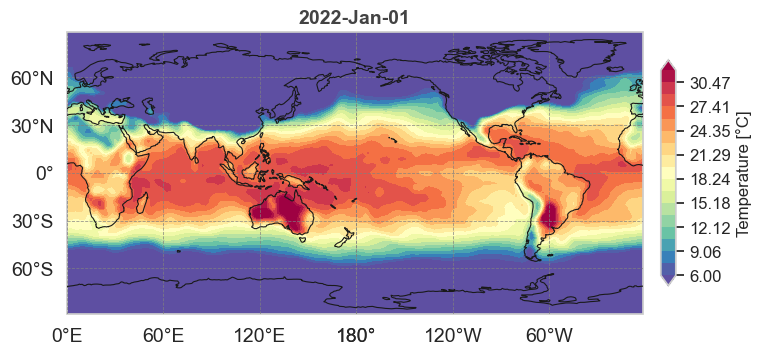

In [4]:
# Define the map projection (PlateCarree) and set the image extent
proj = ccrs.PlateCarree(central_longitude=180)
num_rows = 1
num_columns = 1

# Use the function to calculate properties of the grid
grid_prop = x_coords, y_coords, x_fig, y_fig = cg.define_grid_fig(
    num_rows, num_columns)

# Create a figure with a specified size
fig = plt.figure(figsize=(6, 3))

# Initialize the index for selecting time slices of the temperature data
idx = 0
# Define the contour levels for the temperature plot
levels = np.linspace(6, 32, 18)

# Define the colormap for the plot
cmap = sns.color_palette("Spectral_r", as_cmap=True)

# Loop through each row and column to create a grid of subplots
for fi in range(num_rows):
    for ci in range(num_columns):
        # Add axes to the figure with the calculated properties
        ax = fig.add_axes([x_coords[ci], y_coords[fi],
                            x_fig, y_fig],
                            projection=proj)
        # Add geographic features to the plot
        
        # map resolution is set to 10m, [10, 50 and 110] are available
        ax = cg.add_map_features(ax, lon_step=60, lat_step=30,
                                 map_resolution=110)

        # Set aspect ratio of the plot
        ax.set_aspect('auto')

        # Remove y-axis labels for subplots that aren't in the first column
        if ci > 0:
            ax.set_yticklabels([])

        # Remove x-axis labels for subplots that are not in the last row
        if fi < (num_rows - 1):
            ax.set_xticklabels([])

        # Plot the temperature data for the current time slice
        cs = ax.contourf(lon, lat, air[idx, 0, :, :], levels,
                            cmap=cmap, extend='both', transform=ccrs.PlateCarree())

        # Add a title to each subplot
        ax.set_title(f"{time[idx].strftime('%Y-%b-%d')}",
                        fontdict=font_prop_title)

        # Increment the index to move to the next time slice
        idx += 1

# Define the orientation and label of the colorbar
label = 'Temperature [°C]'

# Add a vertical colorbar to the figure (optional)
cg.add_colorbar(fig, cs, label, 'vertical', grid_prop,
                cbar_factor=0.8, cbar_width=0.025)

fig.savefig(f'figures/example_1.png', dpi=150,
            bbox_inches='tight', transparent=False,
            facecolor='white')

We could also add an horizontal colorbar:

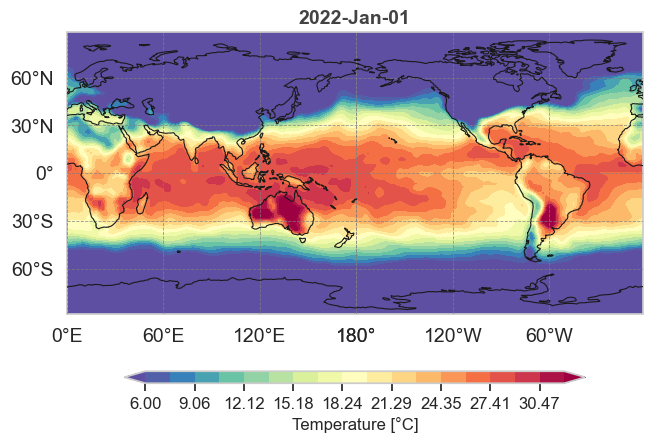

In [5]:
# Define the map projection (PlateCarree) and set the image extent
proj = ccrs.PlateCarree(central_longitude=180)
num_rows = 1
num_columns = 1

# Use the function to calculate properties of the grid
grid_prop = x_coords, y_coords, x_fig, y_fig = cg.define_grid_fig(
    num_rows, num_columns)

# Create a figure with a specified size
fig = plt.figure(figsize=(6, 3))

# Initialize the index for selecting time slices of the temperature data
idx = 0
# Define the contour levels for the temperature plot
levels = np.linspace(6, 32, 18)

# Define the colormap for the plot
cmap = sns.color_palette("Spectral_r", as_cmap=True)

# Loop through each row and column to create a grid of subplots
for fi in range(num_rows):
    for ci in range(num_columns):
        # Add axes to the figure with the calculated properties
        ax = fig.add_axes([x_coords[ci], y_coords[fi],
                            x_fig, y_fig],
                            projection=proj)
        # Add geographic features to the plot
        
        # map resolution is set to 10m, [10, 50 and 110] are available
        ax = cg.add_map_features(ax, lon_step=60, lat_step=30,
                                 map_resolution=110)

        # Set aspect ratio of the plot
        ax.set_aspect('auto')

        # Remove y-axis labels for subplots that aren't in the first column
        if ci > 0:
            ax.set_yticklabels([])

        # Remove x-axis labels for subplots that are not in the last row
        if fi < (num_rows - 1):
            ax.set_xticklabels([])

        # Plot the temperature data for the current time slice
        cs = ax.contourf(lon, lat, air[idx, 0, :, :], levels,
                            cmap=cmap, extend='both',
                            transform=ccrs.PlateCarree())

        # Add a title to each subplot
        ax.set_title(f"{time[idx].strftime('%Y-%b-%d')}",
                        fontdict=font_prop_title)

        # Increment the index to move to the next time slice
        idx += 1

# Define the orientation and label of the colorbar
label = 'Temperature [°C]'

# Add a vertical colorbar to the figure (optional)
cg.add_colorbar(fig, cs, label, 'horizontal', grid_prop,
                cbar_factor=0.8, cbar_width=0.04, y_coord_cbar=-0.2)

fig.savefig(f'figures/example_2.png', dpi=150,
            bbox_inches='tight', transparent=False,
            facecolor='white')

## Adding different colorbar to a single figure

In the following example, we want to plot both the temperature fields along with its anomalies.

The first row plots temperature fields, while the second row plots temperature anomalies, each using its own colormap—different colormaps can be assigned to different rows as needed.



For each row of subplots, we add a colorbar using `cg.add_colorbar_row()`.

```python
cg.add_colorbar_row(fig, cs, label,
                    grid_prop=grid_prop,
                    row_idx=0,
                    cbar_factor=1,
                    cbar_width=0.02,
                    )
````

Each parameter controls where and how the colorbar appears:

* `fig`: the main figure where the colorbar will be drawn.
* `cs` / `cs_anom`: the contour object created by contourf; this tells the function what colors and levels to use.
* `label` / `label_anom`: the text that appears next to the colorbar (e.g., “Temperature [°C]”).
* `grid_prop`: information about the layout of the grid (rows, columns, spacing) so the colorbar can be placed correctly.
* `row_idx`: which row the colorbar belongs to
    * `0`: the first row
    * `1`: the second row
* `cbar_factor`: scales the colorbar height relative to the subplot row (1 = full height).
* `cbar_width`: the thickness of the colorbar (e.g., 0.02 = narrow).

Each row gets its own colorbar, allowing different colormaps to be used for different rows.


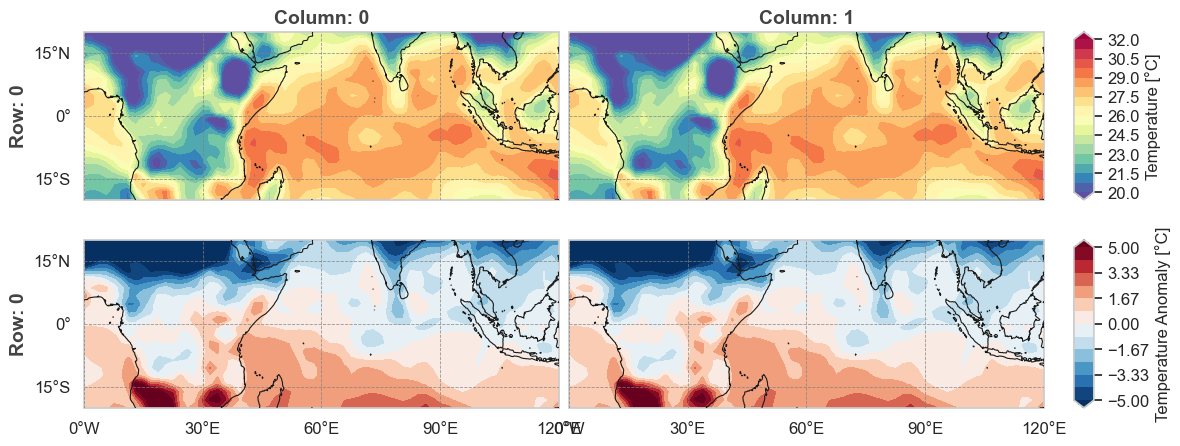

In [6]:
# Define the map projection (PlateCarree) and set the image extent
proj = ccrs.PlateCarree(central_longitude=0)
img_extent = (0, 120, -20, 20)


# Create a figure with a specified size
fig = plt.figure(figsize=(10, 4))

# Define the grid size (number of rows and columns)
num_rows = 2
num_columns = 2
# Define properties for the grid
horiz_spacing = 0.01
vert_spacing = 0.1

# Use the function to calculate properties of the grid
grid_prop = x_coords, y_coords, x_fig, y_fig = cg.define_grid_fig(
    num_rows, num_columns,
    horiz_spacing=horiz_spacing, vert_spacing=vert_spacing)

# Initialize the index for selecting time slices of the temperature data
idx = 0

# Define the contour levels for the temperature plot
levels = np.linspace(20, 32, 17)
levels_anom = np.linspace(-5, 5, 13)

# Define the colormap for the plot
cmap = sns.color_palette("Spectral_r", as_cmap=True)
cmap_anom = sns.color_palette("RdBu_r", as_cmap=True)



# Define properties for the map features
map_prop = {'lon_step': 30,
            'lat_step': 15,
            'map_resolution': 50,
            'fontsize_latlon': 12}

# Loop through each row and column to create a grid of subplots
ri = 0

# Loop through each row and column to create a grid of subplots
for ri in range(num_rows):
    for ci in range(num_columns):
        # Add axes to the figure with the calculated properties
        ax = fig.add_axes([x_coords[ci], y_coords[ri],
                        x_fig, y_fig],
                        projection=proj)
        # Add geographic features to the plot
        ax = cg.add_map_features(ax, **map_prop)

        # Set the image extent and aspect ratio of the plot
        ax.set_extent(img_extent, proj)
        ax.set_aspect('auto')

        # Remove y-axis labels for subplots that aren't in the first column
        if ci > 0:
            ax.set_yticklabels([])

        # Remove x-axis labels for subplots that are not in the last row
        if ri < (num_rows - 1):
            ax.set_xticklabels([])

        if ri == 0:
            # Plot the temperature data for the current time slice
            cs = ax.contourf(lon, lat, air[idx, 0, :, :], levels,
                            cmap=cmap, extend='both',
                            transform=ccrs.PlateCarree())
        else:
            # Plot the temperature data for the current time slice
            cs_anom = ax.contourf(lon, lat, air_anom[idx, 0, :, :],
                                  levels_anom,
                                  cmap=cmap_anom, extend='both',
                                  transform=ccrs.PlateCarree())

        if ci == 0:
            plt.ylabel(f'Row: {fi}', fontdict=font_prop_title)
            
        if ri == 0:
            plt.title(f'Column: {ci}', fontdict=font_prop_title)

# Define the colorbar
label = 'Temperature [°C]'
cg.add_colorbar_row(fig, cs, label,
                    grid_prop=grid_prop,
                    row_idx=0,
                    cbar_factor=1,
                    cbar_width=0.02,
                    )

label_anom = 'Temperature Anomaly [°C]'
cg.add_colorbar_row(fig, cs_anom, label_anom,
                    grid_prop=grid_prop,
                    row_idx=1,
                    cbar_factor=1,
                    cbar_width=0.02,
                    )

fig.savefig(f'figures/example_3.png', dpi=150,
            bbox_inches='tight', transparent=False,
            facecolor='white')

It is also posssible to add the colorbar to a specific colummn using the using `cg.add_colorbar_col()`.

```python
cg.add_colorbar_col(fig, cs, label,
                    grid_prop=grid_prop,
                    col_idx=0,
                    cbar_factor=1,
                    cbar_width=0.05,
                    y_coord_cbar=-0.2
                    )
```
The main parameters are:


* `col_idx`: The column number where the colorbar should be placed
* `cbar_factor`: A scaling factor that adjusts the height of the colorbar relative to the subplot column.
* `cbar_width`: How wide the colorbar is (in figure coordinates).
* `y_coord_cbar`: Vertical shift of the colorbar. Negative values move it down; positive values would move it up. This is useful when placing colorbars below all plots.


Notice that in this example, each column’s colorbar uses different values for `cbar_factor`, `cbar_width`, and `y_coord_cbar`. These variations change the height, thickness, and vertical position of the colorbars, producing a distinct visual effect in the final figure.

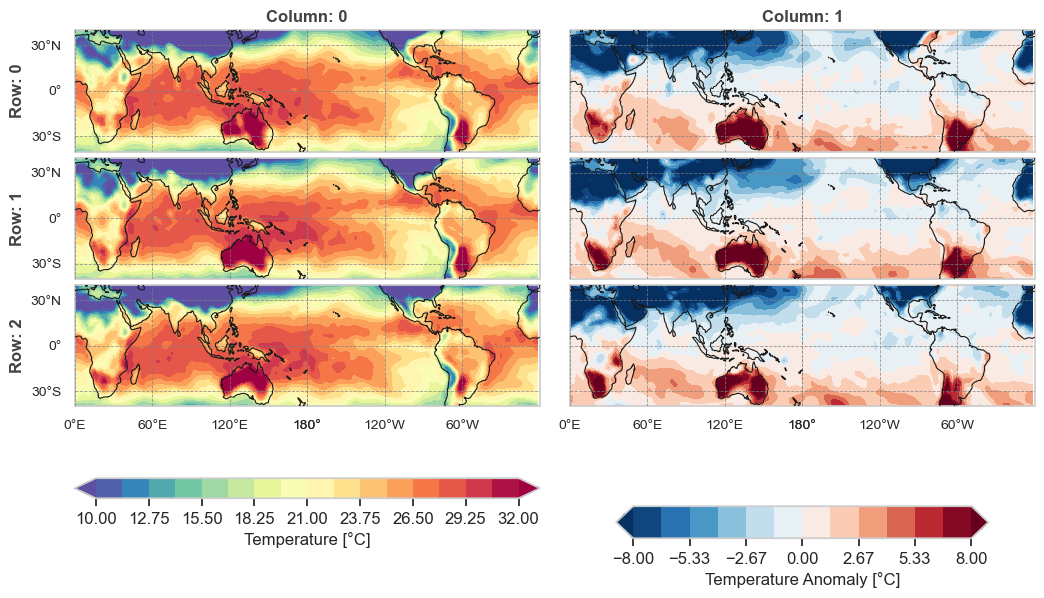

In [7]:
# Define the map projection (PlateCarree) and set the image extent
proj = ccrs.PlateCarree(central_longitude=180)
img_extent = (-180, 180, -40, 40)


# Create a figure with a specified size
fig = plt.figure(figsize=(10, 4))

# Define the grid size (number of rows and columns)
num_rows = 3
num_columns = 2

# Define properties for the grid
horiz_spacing = 0.03
vert_spacing = 0.015

# Use the function to calculate properties of the grid
grid_prop = x_coords, y_coords, x_fig, y_fig = cg.define_grid_fig(
    num_rows, num_columns,
    horiz_spacing=horiz_spacing, vert_spacing=vert_spacing)

# Define font properties for axis labels and title
font_prop = {'fontsize': 12, 'fontweight': 'semibold', 'color': '#434343'}
font_prop_title = {'fontsize': 12,
                    'fontweight': 'semibold', 'color': '#434343'}


# Define the contour levels for the temperature plot
levels = np.linspace(10, 32, 17)
levels_anom = np.linspace(-8, 8, 13)

# Define the colormap for the plot
cmap = sns.color_palette("Spectral_r", as_cmap=True)
cmap_anom = sns.color_palette("RdBu_r", as_cmap=True)



# Define properties for the map features
map_prop = {'lon_step': 60,
            'lat_step': 30,
            'map_resolution': 110,
            'fontsize_latlon': 10}

# Loop through each row and column to create a grid of subplots
for ri in range(num_rows):
    for ci in range(num_columns):
        # Add axes to the figure with the calculated properties
        ax = fig.add_axes([x_coords[ci], y_coords[ri],
                            x_fig, y_fig],
                            projection=proj)
        # Add geographic features to the plot
        ax = cg.add_map_features(ax, **map_prop)

        # Set the image extent and aspect ratio of the plot
        ax.set_aspect('auto')
        ax.set_extent(img_extent, proj)

        # Remove y-axis labels for subplots that aren't in the first column
        if ci > 0:
            ax.set_yticklabels([])

        # Remove x-axis labels for subplots that are not in the last row
        if ri < (num_rows - 1):
            ax.set_xticklabels([])
            
        if ci == 0:
            # Plot the temperature data for the current time slice
            cs = ax.contourf(lon, lat, air[idx, 0, :, :], levels,
                            cmap=cmap, extend='both',
                            transform=ccrs.PlateCarree())
        else:
            # Plot the temperature data for the current time slice
            cs_anom = ax.contourf(lon, lat, air_anom[idx, 0, :, :],
                                  levels_anom,
                                  cmap=cmap_anom, extend='both',
                                  transform=ccrs.PlateCarree())

        if ci == 0:
            plt.ylabel(f'Row: {ri}', fontdict=font_prop_title)
            
            
        if ri == 0:
            plt.title(f'Column: {ci}', fontdict=font_prop_title)

        # Increment the index to move to the next time slice
        idx += 1


# Define the orientation and label of the colorbar
label = 'Temperature [°C]'
cg.add_colorbar_col(fig, cs, label,
                    grid_prop=grid_prop,
                    col_idx=0,
                    cbar_factor=1,
                    cbar_width=0.05,
                    y_coord_cbar=-0.2
                    )

label_anom = 'Temperature Anomaly [°C]'
cg.add_colorbar_col(fig, cs_anom, label_anom,
                    grid_prop=grid_prop,
                    col_idx=1,
                    cbar_factor=0.8,
                    cbar_width=0.08,
                    y_coord_cbar=-0.3
                    )


fig.savefig(f'figures/example_4.png', dpi=150,
            bbox_inches='tight', transparent=False,
            facecolor='white')